#**<center>$\color{green}{\text{TUGAS 2 : KLASIFIKASI}}$</center>**

> Add blockquote



---


<p>
Universitas Terbuka adalah sebuah perguruan tinggi terbuka yang memberikan kesempatan bagi putra putri bangsa untuk menimba ilmu dan pengetahuan. UT memiliki mahasiswa dengan latar belakang yang beragam. Mahasiswanya tidak terbatas pada lulusan baru dari sma/smu/smk sederajat. Beberapa diantaranya bahkan telah/sedang bekerja. Kondisi tersebut memberikan kesulitan bagi pihak kampus dalam menerapkan strategi untuk membantu mahasiswa berhasil melewati masa kuliah dan lulus tepat waktu.
</p>

<p>
Sebagai seorang Machine Learning engineer, kamu diminta untuk membuat model yang mampu mendeteksi secara dini tigkat resiko kegagalan seorang mahasiswa. Dengan harapan jika sistem mampu memberikan informasi yang valid, maka bagian wali akademik dapat memberikan konseling yang tepat. Untuk melaksanakan tugasmu ini, kamu diberikan data yang bersumber dari dua periode penerimaan.
</p>


##Task 1
Mulailah memuat semua data yang ada ke sistem.

In [3]:
# Import library

import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1) Muat data dari kedua sumber
# ...

data_periode1 = pd.read_csv("/content/Data Siswa Periode 1.csv")
data_periode2 = pd.read_csv("/content/Data Siswa Periode 2.csv")

# jumlah baris dan kolom
print("Ukuran data periode 1:", data_periode1.shape)
print("Ukuran data periode 2:", data_periode2.shape)

# 5 data pertama
display(data_periode1.head())
display(data_periode2.head())



Ukuran data periode 1: (1827, 21)
Ukuran data periode 2: (1730, 21)


,ID,Status Pernikahan,Program Studi,Kelas Reguler/Malam,Pendidikan Terakhir,Nilai SMA,Daerah Asal,Pendidikan Ibu,Pendidikan Ayah,Pekerjaan Ibu,...,Nilai Ujian Masuk,Pindahan,Berkebutuhan Khusus,Status pembayaran semester terakhir,Jenis Kelamin,Beasiswa,Usia saat mendaftar,IP Semester 1,IP Semester 2,Target
0,2,Belum Menikah,Teknik Industri,Reguler,SMA/Sederajat,66.55,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Lainnya,...,53.00,Ya,Tidak,Sudah,Pria,Tidak,21,2.48,2.52,Lulus Tepat Waktu
1,3,Belum Menikah,Jurnalistik,Reguler,SMA/Sederajat,63.50,Pulau Jawa,SMA/Sederajat,Lebih dari S1,Pegawai Swasta,...,58.25,Tidak,Tidak,Sudah,Wanita,Ya,19,2.86,2.63,Lulus Tepat Waktu
2,4,Belum Menikah,Pertanian,Reguler,SMA/Sederajat,62.50,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Wiraswasta,...,60.75,Ya,Tidak,Sudah,Pria,Tidak,18,2.20,2.07,Lulus Tidak Tepat Waktu
3,5,Belum Menikah,Teknik Mesin,Reguler,Perguruan Tinggi,75.00,Pulau Jawa,Lebih dari S1,Lebih dari S1,Pegawai Swasta,...,75.00,Tidak,Tidak,Sudah,Wanita,Tidak,20,2.60,2.40,Lulus Tidak Tepat Waktu
4,10,Belum Menikah,Perbankan,Reguler,SMA/Sederajat,65.00,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Pegawai Negri,...,64.55,Ya,Tidak,Sudah,Wanita,Tidak,18,2.61,2.72,Lulus Tepat Waktu


,ID,Status Pernikahan,Program Studi,Kelas Siang/Malam,Pendidikan Terakhir,Nilai SMA,Daerah Asal,Pendidikan Ibu,Pendidikan Ayah,Pekerjaan Ibu,...,Nilai Ujian Masuk,Pindahan,Berkebutuhan Khusus,Status pembayaran semester terakhir,Jenis Kelamin,Beasiswa,Umur saat mendaftar,IP Semester 1,IP Semester 2,Target
0,1817,Belum Menikah,Perbankan,Siang,SMA/Sederajat,66.0,Pulau Jawa,Dibawah SMA/Sederajat,Dibawah SMA/Sederajat,Lainnya,...,62.75,Ya,Tidak,Sudah,Laki-laki,Tidak,18,2.63,2.63,Lulus Tidak Tepat Waktu
1,1819,Belum Menikah,Teknik Industri,Siang,SMA/Sederajat,61.0,Pulau Jawa,Dibawah SMA/Sederajat,Dibawah SMA/Sederajat,Wiraswasta,...,58.55,Ya,Tidak,Sudah,Perempuan,Tidak,19,2.42,0.00,Gagal
2,1820,Belum Menikah,Akuntansi,Siang,SMA/Sederajat,73.5,Pulau Jawa,Lebih dari S1,Lebih dari S1,Lainnya,...,64.40,Tidak,Tidak,Sudah,Perempuan,Tidak,19,2.00,0.00,Gagal
3,1821,Belum Menikah,Perbankan,Siang,SMA/Sederajat,68.0,Pulau Jawa,Dibawah SMA/Sederajat,SMA/Sederajat,Pegawai Negri,...,68.20,Tidak,Tidak,Sudah,Perempuan,Ya,19,2.57,3.10,Lulus Tepat Waktu
4,1822,Belum Menikah,Teknik Industri,Siang,SMA/Sederajat,70.0,Pulau Jawa,Dibawah SMA/Sederajat,Dibawah SMA/Sederajat,Lainnya,...,65.80,Ya,Tidak,Sudah,Laki-laki,Tidak,19,0.00,0.00,Gagal


In [4]:
# 2) Lihat atribut apa saja yang ada dari kedua data tersebut
# ...

print("Atribut data periode 1:")
print(data_periode1.columns.tolist())

print("\nAtribut data periode 2:")
print(data_periode2.columns.tolist())

Atribut data periode 1:
['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Reguler/Malam', 'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa', 'Usia saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']

Atribut data periode 2:
['ID', 'Status Pernikahan', 'Program Studi', 'Kelas Siang/Malam', 'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa', 'Umur saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']


##Task 2
Datanya sudah termuat, fitur nya hampir semuanya sama, tetapi ada yang berbeda sehingga perlu dipetakan

In [5]:
# 1) Identifikasi fitur serupa, lakukan penamaan ulang fitur serupa
# ...

# 1) Identifikasi fitur serupa, lakukan penamaan ulang fitur serupa

# Rename kolom pada data periode 1
data_periode1 = data_periode1.rename(columns={
    "Kelas Reguler/Malam": "Kelas"
})

# Rename kolom pada data periode 2
data_periode2 = data_periode2.rename(columns={
    "Kelas Siang/Malam": "Kelas",
    "Umur saat mendaftar": "Usia saat mendaftar"
})

# Cek kembali nama kolom setelah rename
print("Atribut data periode 1 setelah rename:")
print(data_periode1.columns.tolist())

print("\nAtribut data periode 2 setelah rename:")
print(data_periode2.columns.tolist())

Atribut data periode 1 setelah rename:
['ID', 'Status Pernikahan', 'Program Studi', 'Kelas', 'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa', 'Usia saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']

Atribut data periode 2 setelah rename:
['ID', 'Status Pernikahan', 'Program Studi', 'Kelas', 'Pendidikan Terakhir', 'Nilai SMA', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Nilai Ujian Masuk', 'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa', 'Usia saat mendaftar', 'IP Semester 1', 'IP Semester 2', 'Target']


##Task 3
Butuh penyatuan data, tapi ternyata ada kodefikasi atribut fitur yang berbeda, harus di samakan

In [6]:
# 1) Lakukan penyamaan kodefikasi atribut
# ...

#  kodefikasi pada fitur Kelas
data_periode2["Kelas"] = data_periode2["Kelas"].replace({
    "Siang": "Reguler"
})

# kodefikasi pada fitur Jenis Kelamin
data_periode1["Jenis Kelamin"] = data_periode1["Jenis Kelamin"].replace({
    "Pria": "Laki-laki",
    "Wanita": "Perempuan"
})

# Cek hasil penyamaan kodefikasi
print("Kodefikasi Kelas pada data periode 1:")
print(data_periode1["Kelas"].unique())

print("\nKodefikasi Kelas pada data periode 2:")
print(data_periode2["Kelas"].unique())

print("\nKodefikasi Jenis Kelamin pada data periode 1:")
print(data_periode1["Jenis Kelamin"].unique())

print("\nKodefikasi Jenis Kelamin pada data periode 2:")
print(data_periode2["Jenis Kelamin"].unique())



Kodefikasi Kelas pada data periode 1:
['Reguler' 'Malam' nan]

Kodefikasi Kelas pada data periode 2:
['Reguler' 'Malam']

Kodefikasi Jenis Kelamin pada data periode 1:
['Laki-laki' 'Perempuan']

Kodefikasi Jenis Kelamin pada data periode 2:
['Laki-laki' 'Perempuan']


In [7]:
# Cek jumlah nilai kosong pada fitur Kelas
print("Missing value Kelas periode 1:")
print(data_periode1["Kelas"].isna().sum())

print("\nMissing value Kelas periode 2:")
print(data_periode2["Kelas"].isna().sum())

Missing value Kelas periode 1:
3

Missing value Kelas periode 2:
0


In [8]:
# Menghapus baris yang memiliki missing value pada fitur Kelas di data periode 1
data_periode1 = data_periode1.dropna(subset=["Kelas"])

# Cek ulang missing value pada fitur Kelas
print("Missing value Kelas periode 1 setelah dihapus:")
print(data_periode1["Kelas"].isna().sum())

# Cek ukuran data setelah penghapusan
print("Ukuran data periode 1 setelah hapus missing value:", data_periode1.shape)

Missing value Kelas periode 1 setelah dihapus:
0
Ukuran data periode 1 setelah hapus missing value: (1824, 21)




Missing value pada fitur Kelas di data periode 1 berjumlah 3 data. Karena jumlahnya sangat kecil dibandingkan total data, maka baris yang memiliki nilai kosong tersebut dihapus agar data lebih bersih dan tidak menimbulkan bias saat proses analisis atau pemodelan.


In [9]:
# 2) Lakukan penyatuan data
# ...
# Menyatukan data periode 1 dan periode 2
data_gabungan = pd.concat(
    [data_periode1, data_periode2],
    ignore_index=True
)

# Cek ukuran data gabungan
print("Ukuran data gabungan:", data_gabungan.shape)

Ukuran data gabungan: (3554, 21)


##Task 4
Sekarang kita lakukan analisis atribut untuk setiap fitur nya, mulai dengan penanganan missing/null value

In [10]:
# 1)	Identifikasi dan tangani missing/null value
# ...


# Mengecek jumlah missing value pada setiap fitur
missing_value = data_gabungan.isnull().sum()

# Menampilkan hanya fitur yang memiliki missing value
missing_value[missing_value > 0]

,0
Daerah Asal,3


In [11]:
# Menangani missing value pada fitur Daerah Asal
data_gabungan = data_gabungan.dropna(subset=["Daerah Asal"])

# Cek ulang missing value
missing_value = data_gabungan.isnull().sum()

print("Fitur yang masih memiliki missing value:")
print(missing_value[missing_value > 0])

print("\nTotal missing value:", data_gabungan.isnull().sum().sum())

print("\nUkuran data setelah menghapus missing value Daerah Asal:")
print(data_gabungan.shape)

Fitur yang masih memiliki missing value:
Series([], dtype: int64)

Total missing value: 0

Ukuran data setelah menghapus missing value Daerah Asal:
(3551, 21)


In [12]:
data_gabungan.info()

<class 'pandas.core.frame.DataFrame'>
Index: 3551 entries, 0 to 3553
Data columns (total 21 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   ID                                   3551 non-null   int64  
 1   Status Pernikahan                    3551 non-null   object 
 2   Program Studi                        3551 non-null   object 
 3   Kelas                                3551 non-null   object 
 4   Pendidikan Terakhir                  3551 non-null   object 
 5   Nilai SMA                            3551 non-null   float64
 6   Daerah Asal                          3551 non-null   object 
 7   Pendidikan Ibu                       3551 non-null   object 
 8   Pendidikan Ayah                      3551 non-null   object 
 9   Pekerjaan Ibu                        3551 non-null   object 
 10  Pekerjaan Ayah                       3551 non-null   object 
 11  Nilai Ujian Masuk                  

##Task 5
Untuk bisa melihat bentuk dari data, kita perlu menghitung histogram dari setiap fitur. Dari situ kemudian kita bisa lanjutkan dengan penanganan outlier.

In [17]:
# Mengubah nama data_gabungan menjadi df
df = data_gabungan.copy()


# 1)	Hitung histogram setiap fitur, tampilkan dalam bentuk grafik batang
# ...

# Memisahkan fitur numerik dan kategorik
fitur_numerik = df.select_dtypes(include=["int64", "float64"]).columns
fitur_kategorik = df.select_dtypes(include=["object"]).columns

print("Fitur numerik:")
print(fitur_numerik)

print("\nFitur kategorik:")
print(fitur_kategorik)


Fitur numerik:
Index(['ID', 'Nilai SMA', 'Nilai Ujian Masuk', 'Usia saat mendaftar',
       'IP Semester 1', 'IP Semester 2'],
      dtype='object')

Fitur kategorik:
Index(['Status Pernikahan', 'Program Studi', 'Kelas', 'Pendidikan Terakhir',
       'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu',
       'Pekerjaan Ayah', 'Pindahan', 'Berkebutuhan Khusus',
       'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa',
       'Target'],
      dtype='object')


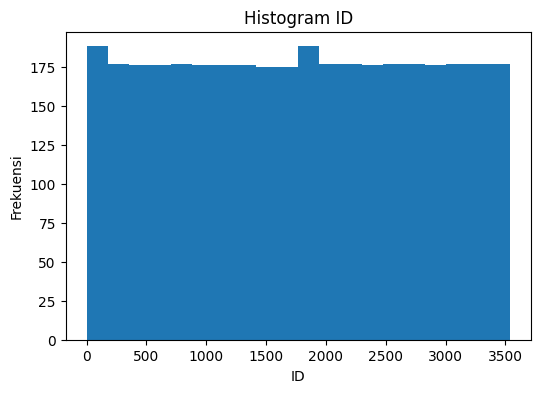

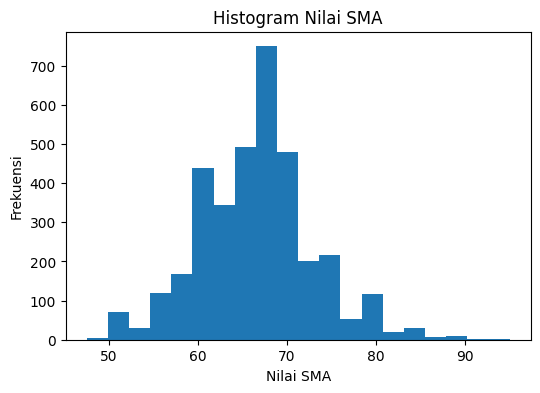

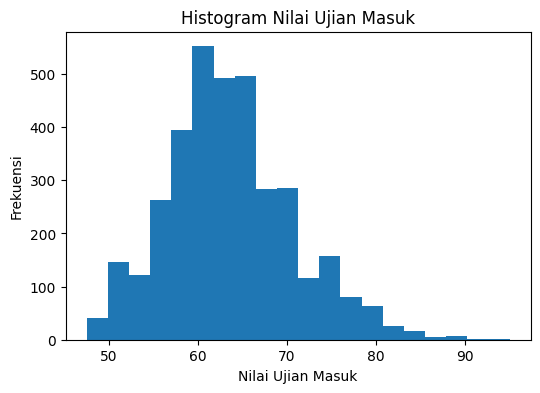

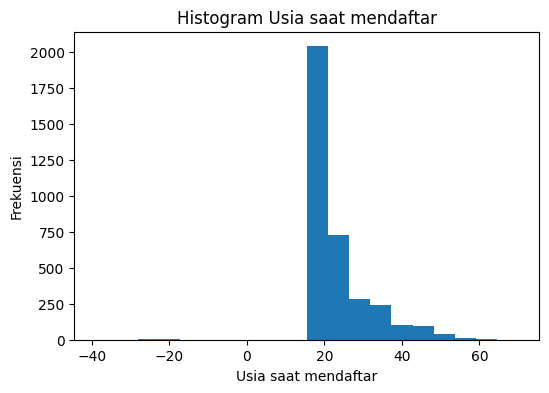

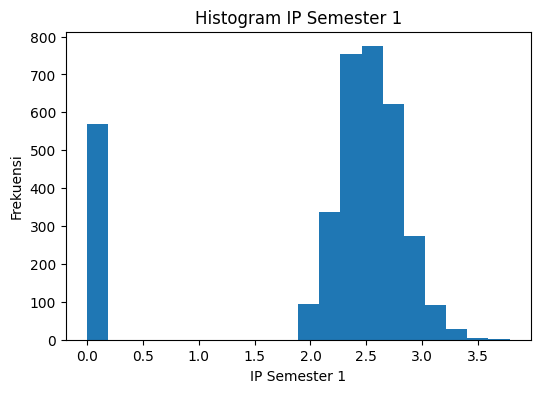

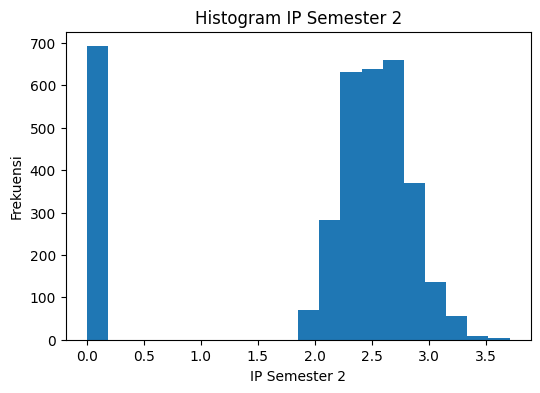

In [15]:
# Histogram untuk setiap fitur numerik

for kolom in fitur_numerik:
    plt.figure(figsize=(6, 4))
    plt.hist(df[kolom], bins=20)
    plt.title(f"Histogram {kolom}")
    plt.xlabel(kolom)
    plt.ylabel("Frekuensi")
    plt.show()

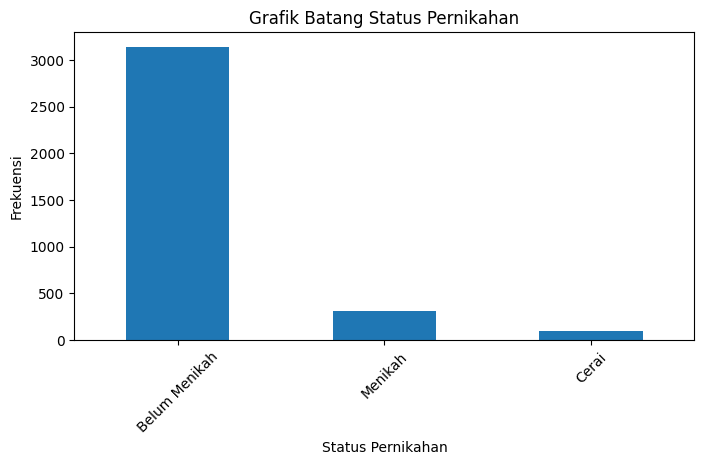

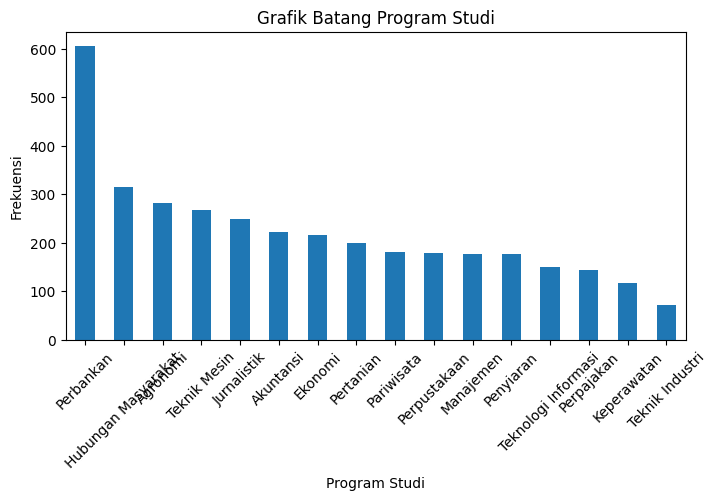

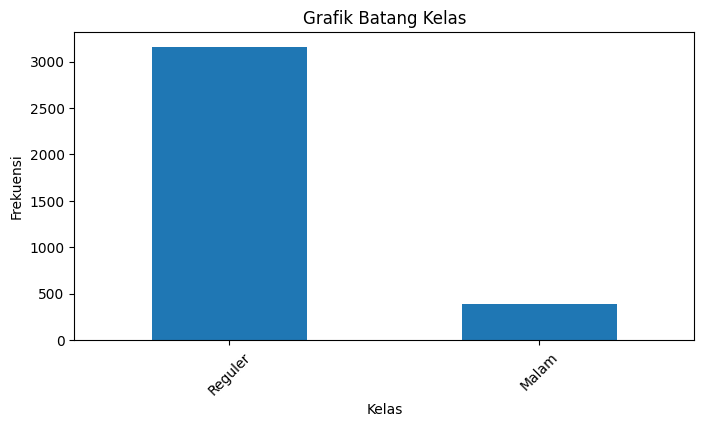

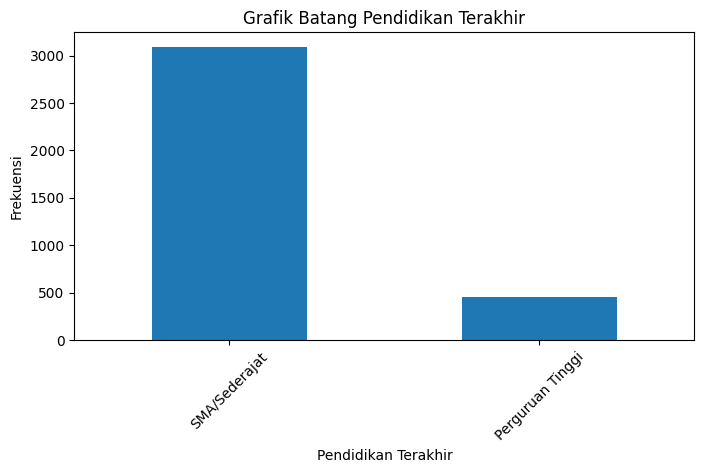

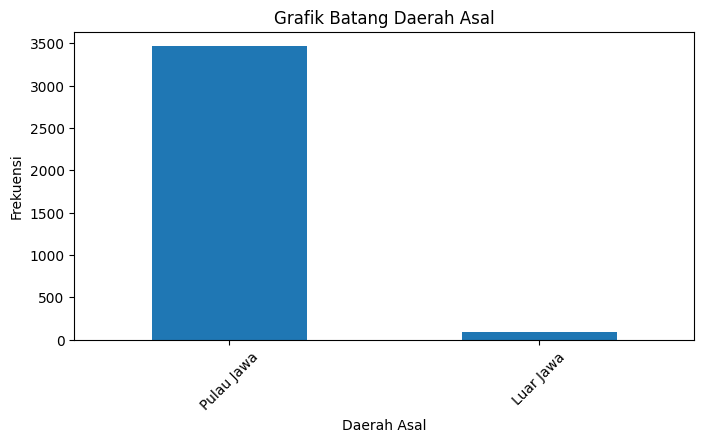

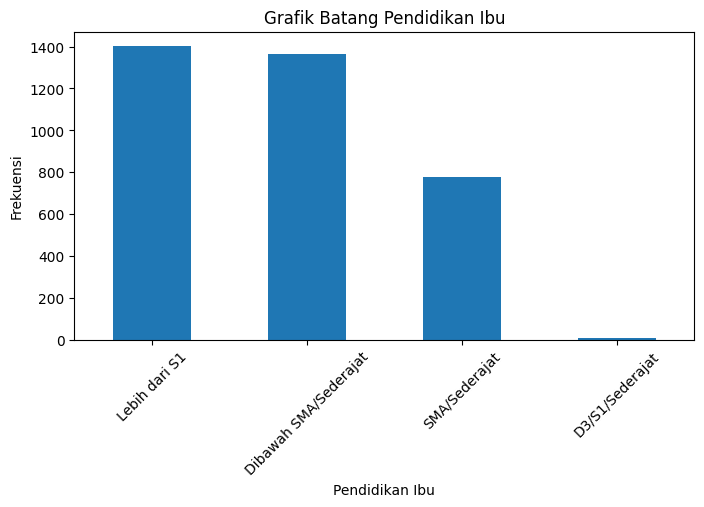

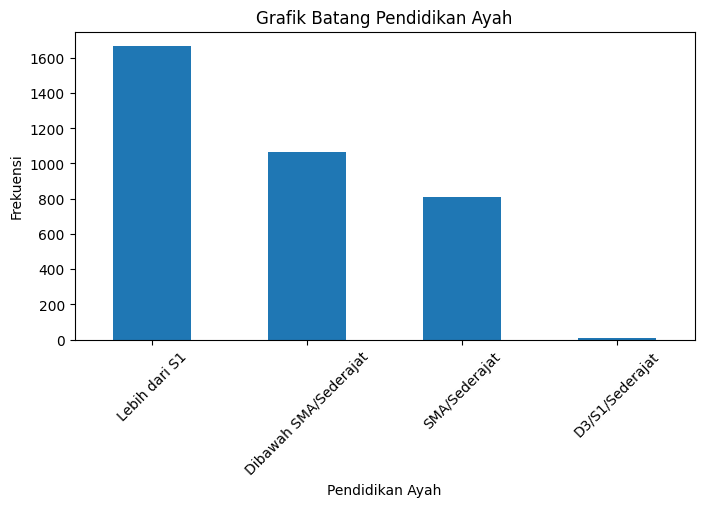

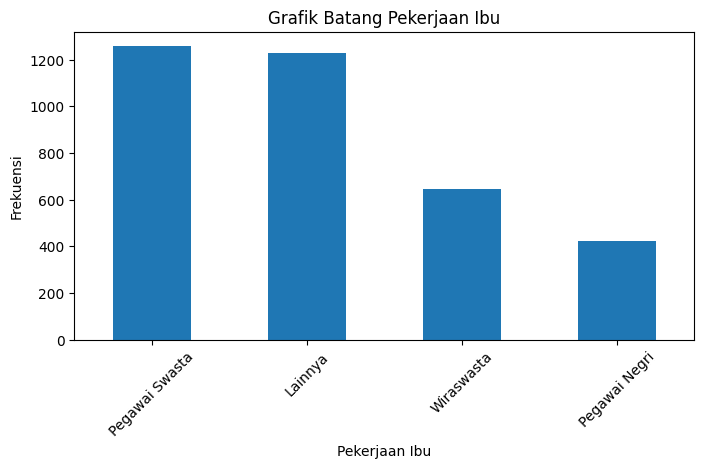

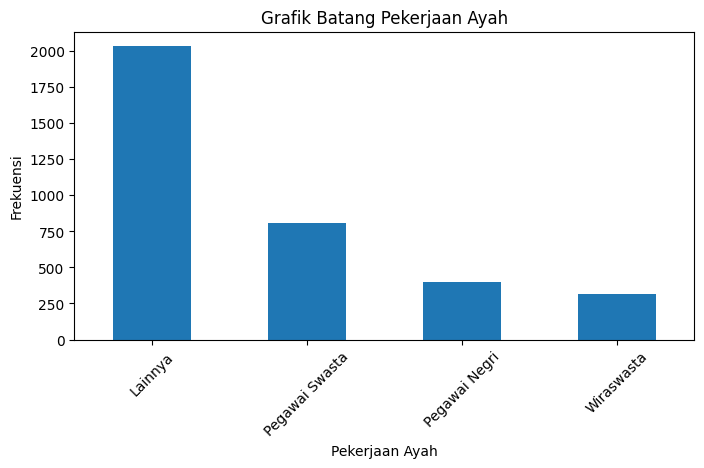

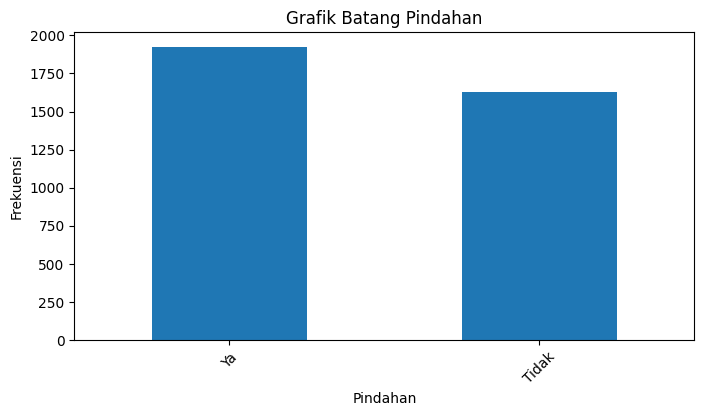

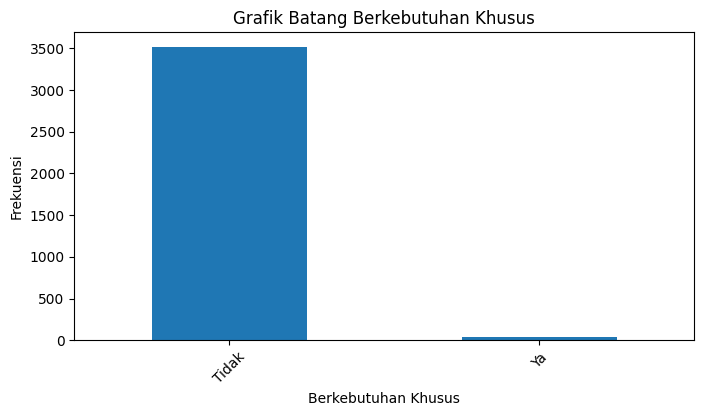

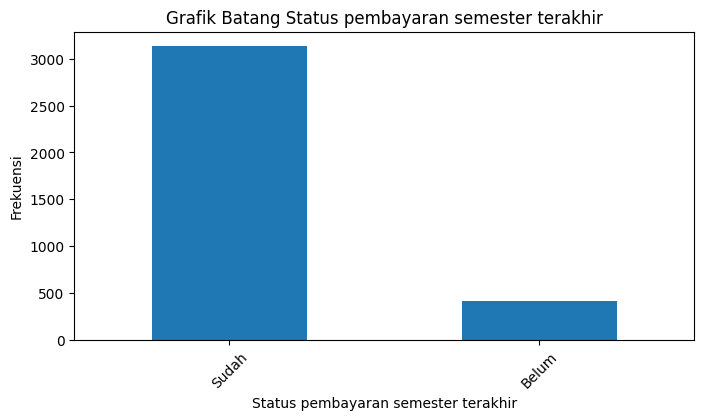

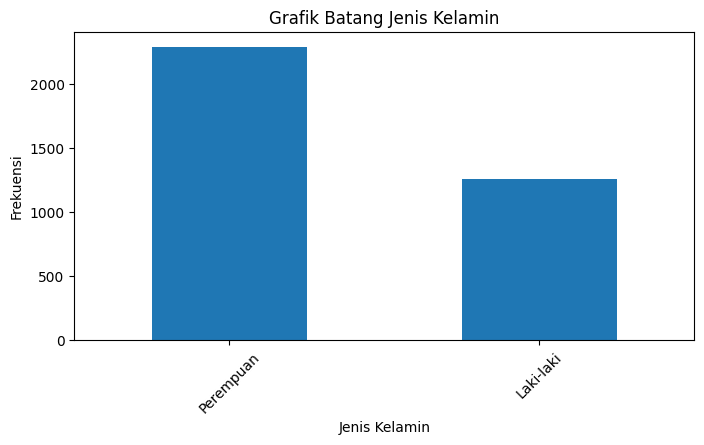

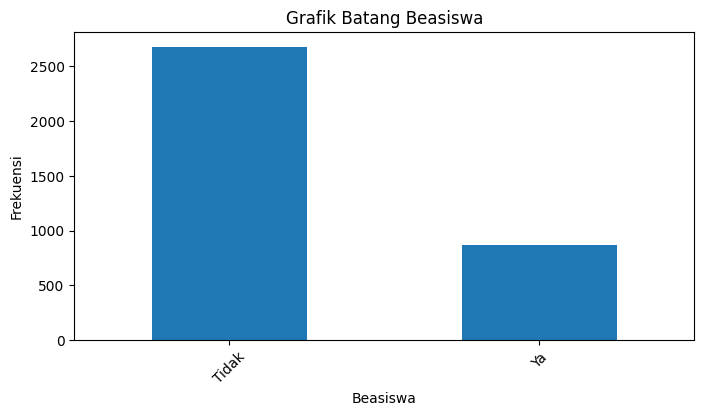

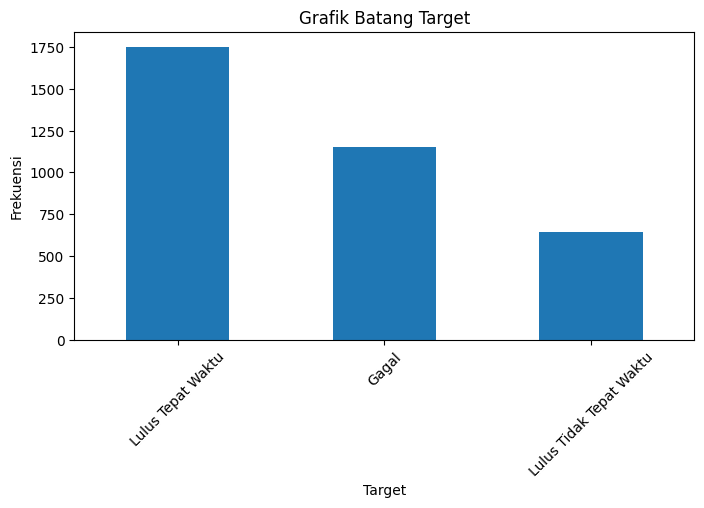

In [16]:
# Grafik batang untuk setiap fitur kategorik

for kolom in fitur_kategorik:
    plt.figure(figsize=(8, 4))
    df[kolom].value_counts().plot(kind="bar")
    plt.title(f"Grafik Batang {kolom}")
    plt.xlabel(kolom)
    plt.ylabel("Frekuensi")
    plt.xticks(rotation=45)
    plt.show()

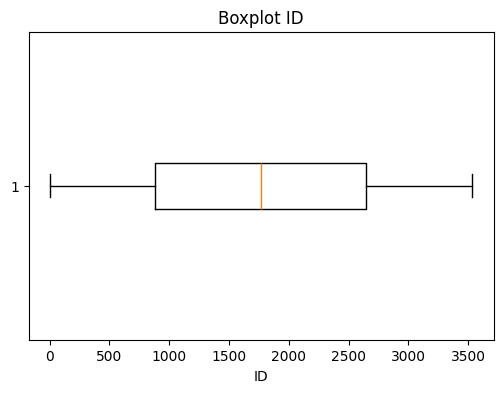

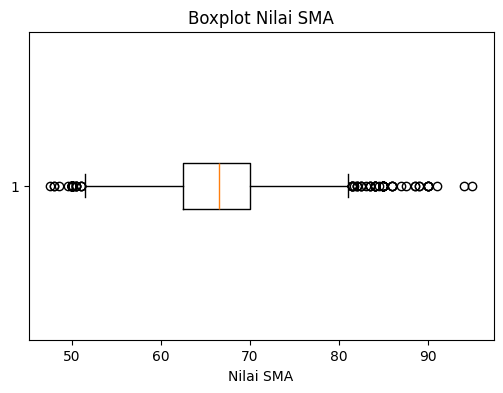

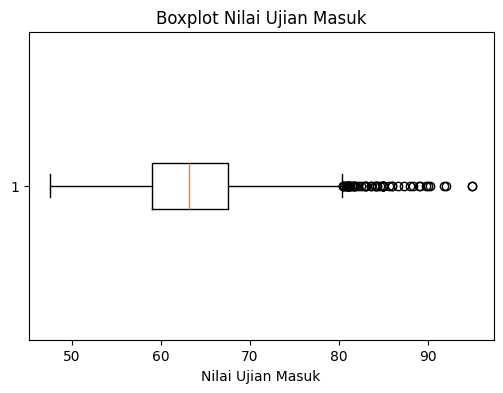

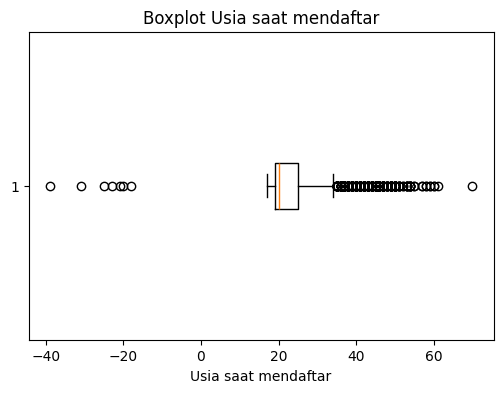

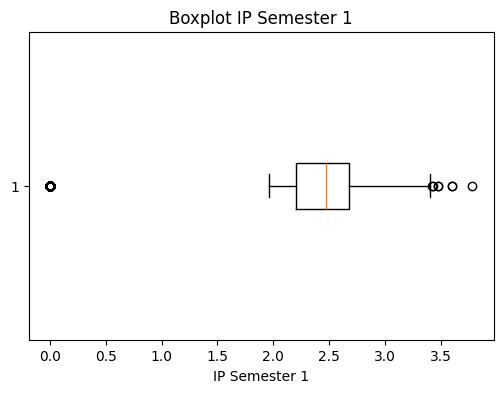

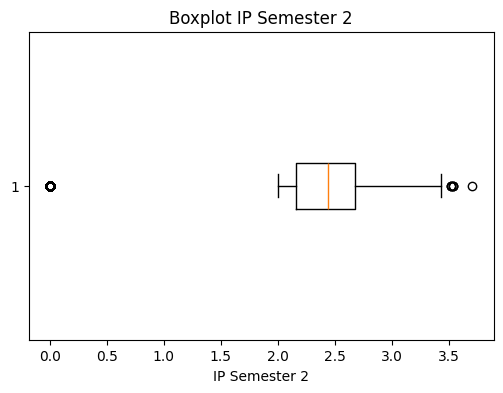

In [19]:
# 2)	Identifikasi outlier dengan boxplot
# ...
# Boxplot untuk identifikasi outlier pada fitur numerik

for kolom in fitur_numerik:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df[kolom].dropna(), vert=False)
    plt.title(f"Boxplot {kolom}")
    plt.xlabel(kolom)
    plt.show()

In [21]:
# 3)	Hapus outlier dari data
# ...
# Fungsi untuk menghapus outlier menggunakan metode IQR

def hapus_outlier_iqr(data, kolom_numerik):
    df_bersih = data.copy()

    for kolom in kolom_numerik:
        Q1 = df_bersih[kolom].quantile(0.25)
        Q3 = df_bersih[kolom].quantile(0.75)
        IQR = Q3 - Q1

        batas_bawah = Q1 - 1.5 * IQR
        batas_atas = Q3 + 1.5 * IQR

        df_bersih = df_bersih[
            (df_bersih[kolom] >= batas_bawah) &
            (df_bersih[kolom] <= batas_atas)
        ]

    return df_bersih

# Menghapus outlier dari data

df_bersih = hapus_outlier_iqr(df, fitur_numerik)

print("Ukuran data sebelum hapus outlier:", df.shape)
print("Ukuran data setelah hapus outlier:", df_bersih.shape)
print("Jumlah data yang terhapus:", df.shape[0] - df_bersih.shape[0])

Ukuran data sebelum hapus outlier: (3551, 21)
Ukuran data setelah hapus outlier: (2378, 21)
Jumlah data yang terhapus: 1173


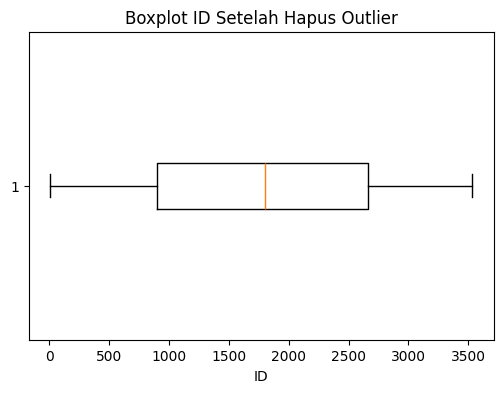

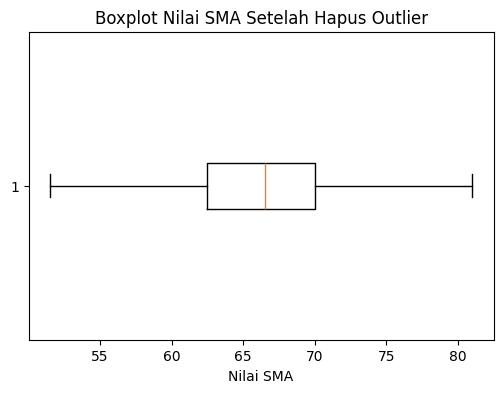

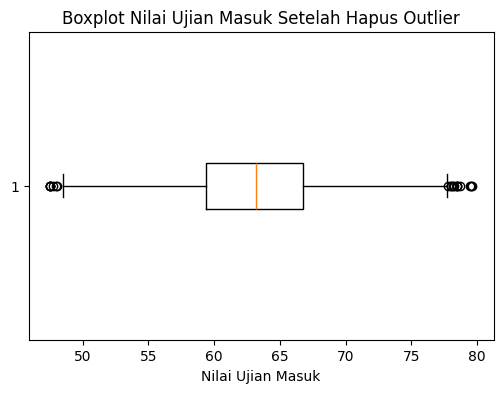

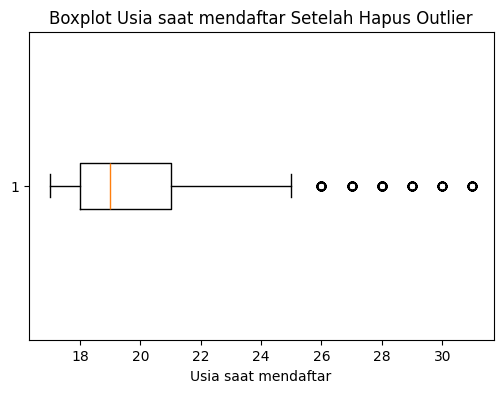

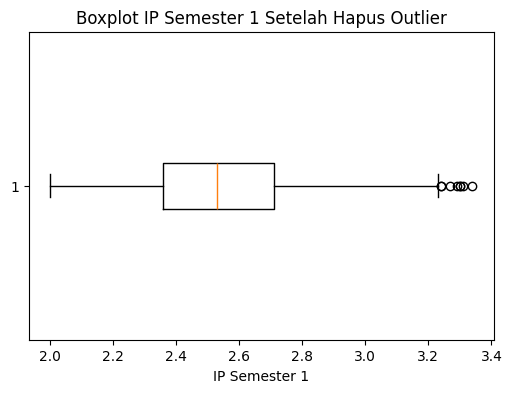

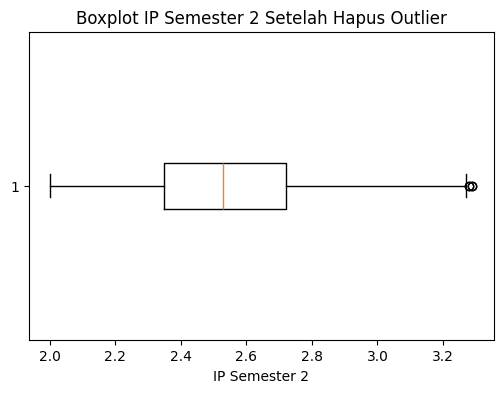

In [22]:
# Boxplot setelah outlier dihapus

for kolom in fitur_numerik:
    plt.figure(figsize=(6, 4))
    plt.boxplot(df_bersih[kolom].dropna(), vert=False)
    plt.title(f"Boxplot {kolom} Setelah Hapus Outlier")
    plt.xlabel(kolom)
    plt.show()

##Task 6
Agar nantinya kita bisa mendapatkan fitur yang relevan, sebaiknya kita melihat hubungan setiap fitur dengan kelas target.

In [23]:
# Memisahkan fitur numerik dan kategorik dari df_bersih
fitur_numerik = df_bersih.select_dtypes(include=["int64", "float64"]).columns.tolist()
fitur_kategorik = df_bersih.select_dtypes(include=["object"]).columns.tolist()

# Menghapus Target dari fitur kategorik
if "Target" in fitur_kategorik:
    fitur_kategorik.remove("Target")

print("Fitur numerik:")
print(fitur_numerik)

print("\nFitur kategorik:")
print(fitur_kategorik)

Fitur numerik:
['ID', 'Nilai SMA', 'Nilai Ujian Masuk', 'Usia saat mendaftar', 'IP Semester 1', 'IP Semester 2']

Fitur kategorik:
['Status Pernikahan', 'Program Studi', 'Kelas', 'Pendidikan Terakhir', 'Daerah Asal', 'Pendidikan Ibu', 'Pendidikan Ayah', 'Pekerjaan Ibu', 'Pekerjaan Ayah', 'Pindahan', 'Berkebutuhan Khusus', 'Status pembayaran semester terakhir', 'Jenis Kelamin', 'Beasiswa']


In [29]:
# 1)	Lakukan analisis bivariate
# ...
# Rata-rata fitur numerik berdasarkan Target
print("Rata-rata fitur numerik berdasarkan Target:")
display(df_bersih.groupby("Target")[fitur_numerik].mean())

Rata-rata fitur numerik berdasarkan Target:


,ID,Nilai SMA,Nilai Ujian Masuk,Usia saat mendaftar,IP Semester 1,IP Semester 2
Target,,,,,,
Gagal,1722.926941,65.464269,62.221689,21.815068,2.427717,2.418562
Lulus Tepat Waktu,1828.880473,66.955038,63.854969,19.832523,2.612891,2.624253
Lulus Tidak Tepat Waktu,1711.309381,65.559082,62.627645,20.560878,2.445409,2.430818


In [25]:
# Median fitur numerik berdasarkan Target
print("Median fitur numerik berdasarkan Target:")
display(df_bersih.groupby("Target")[fitur_numerik].median())

Median fitur numerik berdasarkan Target:


,ID,Nilai SMA,Nilai Ujian Masuk,Usia saat mendaftar,IP Semester 1,IP Semester 2
Target,,,,,,
Gagal,1660.0,65.50,62.075,20.0,2.40,2.40
Lulus Tepat Waktu,1843.0,66.55,63.500,19.0,2.61,2.61
Lulus Tidak Tepat Waktu,1741.0,65.00,62.150,20.0,2.43,2.40


In [26]:
# Crosstab fitur kategorik terhadap Target

for kolom in fitur_kategorik:
    print(f"\nHubungan {kolom} dengan Target:")
    display(pd.crosstab(df_bersih[kolom], df_bersih["Target"]))


Hubungan Status Pernikahan dengan Target:


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Status Pernikahan,,,
Belum Menikah,410,1415,489
Cerai,6,3,7
Menikah,22,21,5



Hubungan Program Studi dengan Target:


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Program Studi,,,
Agronomi,18,183,26
Akuntansi,33,97,37
Ekonomi,25,26,26
Hubungan Masyarakat,51,101,74
Jurnalistik,37,138,23
Keperawatan,32,29,15
Manajemen,19,92,30
Pariwisata,10,41,7
Penyiaran,5,15,8



Hubungan Kelas dengan Target:


...

Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Status pembayaran semester terakhir,,,
Belum,119,15,25
Sudah,319,1424,476



Hubungan Jenis Kelamin dengan Target:


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Jenis Kelamin,,,
Laki-laki,195,312,181
Perempuan,243,1127,320



Hubungan Beasiswa dengan Target:


Target,Gagal,Lulus Tepat Waktu,Lulus Tidak Tepat Waktu
Beasiswa,,,
Tidak,379,871,412
Ya,59,568,89


In [30]:
# 2)	Plot kedalam grafik sebaran (scatter)
# ...

# Melihat nilai unik pada Target
print(df_bersih["Target"].unique())

# Encoding Target menjadi angka untuk scatter plot
df_bersih["Target_encoded"] = df_bersih["Target"].astype("category").cat.codes

# Cek hasil encoding Target
display(df_bersih[["Target", "Target_encoded"]].drop_duplicates())

['Lulus Tepat Waktu' 'Lulus Tidak Tepat Waktu' 'Gagal']


,Target,Target_encoded
0,Lulus Tepat Waktu,1
2,Lulus Tidak Tepat Waktu,2
7,Gagal,0


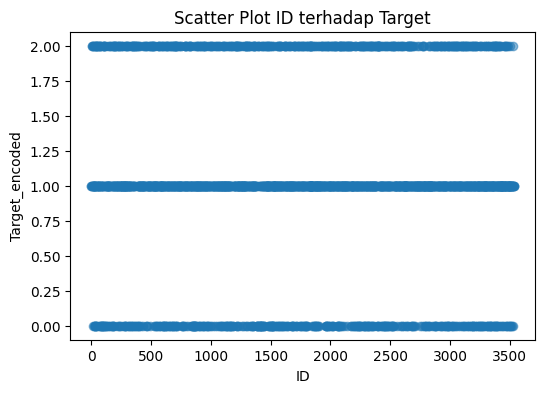

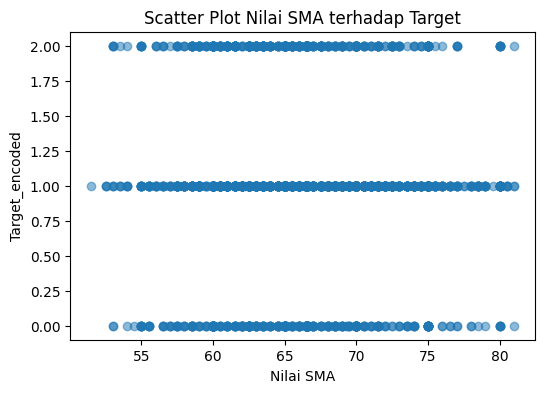

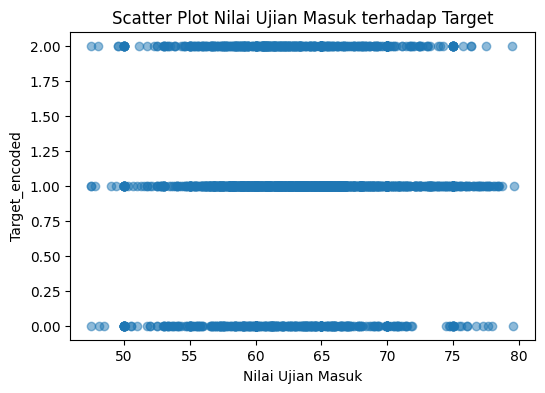

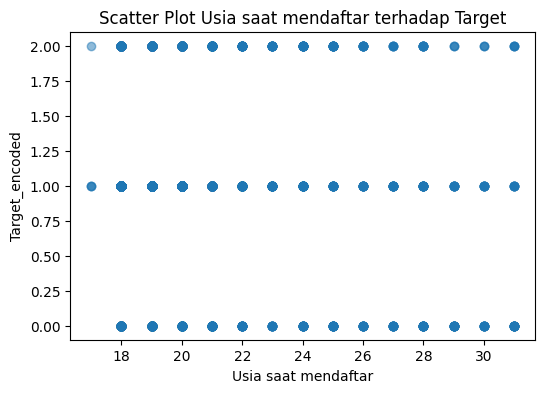

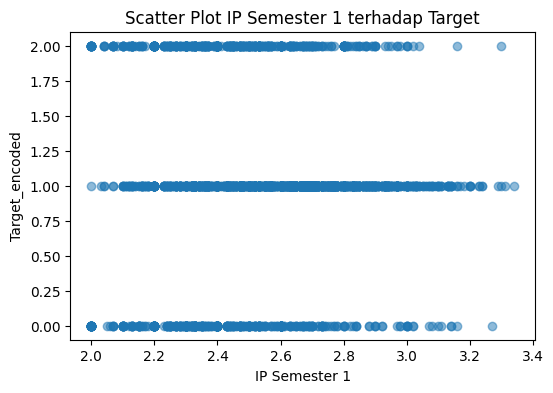

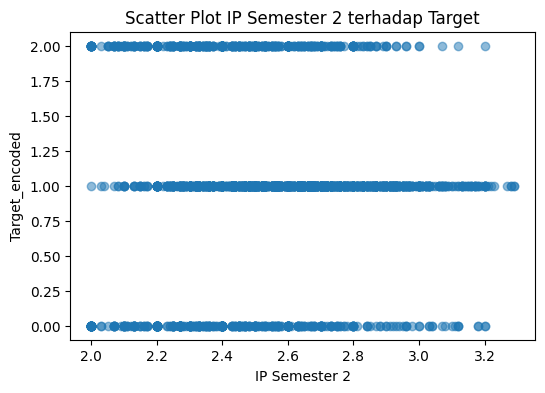

In [31]:
# Scatter plot fitur numerik terhadap Target_encoded

for kolom in fitur_numerik:
    plt.figure(figsize=(6, 4))
    plt.scatter(df_bersih[kolom], df_bersih["Target_encoded"], alpha=0.5)
    plt.title(f"Scatter Plot {kolom} terhadap Target")
    plt.xlabel(kolom)
    plt.ylabel("Target_encoded")
    plt.show()

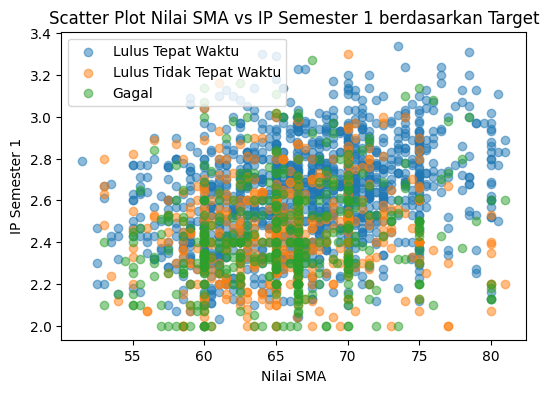

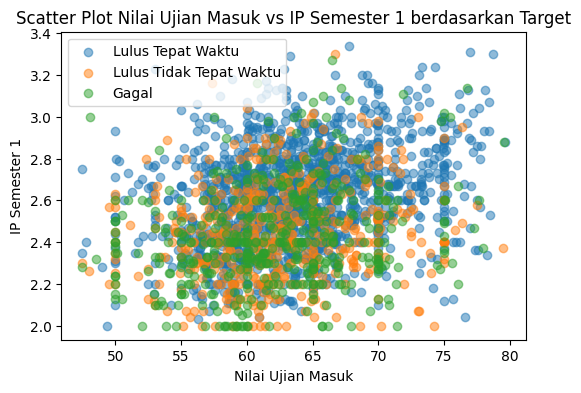

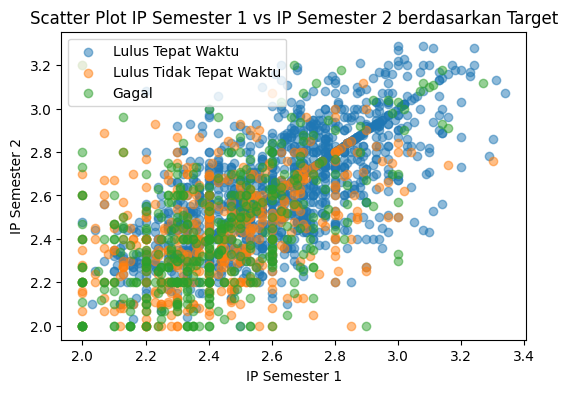

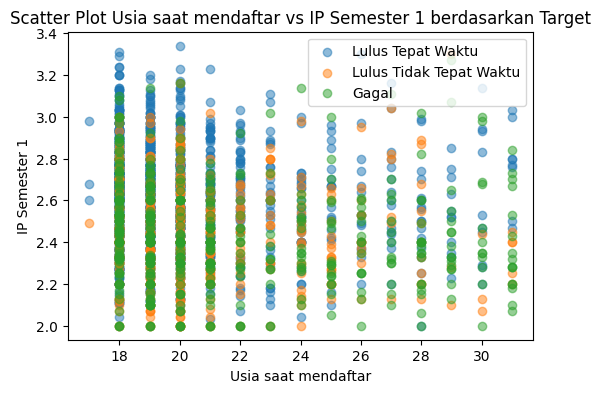

In [32]:
# Scatter plot antar fitur numerik dengan warna berdasarkan Target

pasangan_fitur = [
    ("Nilai SMA", "IP Semester 1"),
    ("Nilai Ujian Masuk", "IP Semester 1"),
    ("IP Semester 1", "IP Semester 2"),
    ("Usia saat mendaftar", "IP Semester 1")
]

for x, y in pasangan_fitur:
    if x in df_bersih.columns and y in df_bersih.columns:
        plt.figure(figsize=(6, 4))

        for target in df_bersih["Target"].unique():
            subset = df_bersih[df_bersih["Target"] == target]
            plt.scatter(subset[x], subset[y], alpha=0.5, label=target)

        plt.title(f"Scatter Plot {x} vs {y} berdasarkan Target")
        plt.xlabel(x)
        plt.ylabel(y)
        plt.legend()
        plt.show()

##Task 7
Oke, sepertinya sudah siap, tapi kok jumlah data per-kelas nya tidak seimbang ya, ada beberapa algoritma yang akan terpengaruh dengan kondisi ini, kita akan gunakan algoritma **$\color{orange}{\text{SMOTE (Synthetic Minority Over-sampling)}}$** untuk menyelesaikan masalah ini, jadi kita **$\color{orange}{\text{akan}}$** melakukan proses augmentasi data karena **$\color{orange}{\text{SMOTE dapat menambah data sintetis pada kelas minoritas sehingga distribusi kelas menjadi lebih seimbang tanpa menghapus data dari kelas mayoritas.}}$**

In [33]:
# 1)	Augmentasi data untuk balancing kelas (Optional)
# ...

# Melihat jumlah data pada setiap kelas Target
print("Distribusi kelas sebelum augmentasi:")
print(df_bersih["Target"].value_counts())

Distribusi kelas sebelum augmentasi:
Target
Lulus Tepat Waktu          1439
Lulus Tidak Tepat Waktu     501
Gagal                       438
Name: count, dtype: int64


In [34]:
# Karena SMOTE hanya bisa bekerja pada data numerik, maka fitur kategorik perlu diubah dulu menjadi numerik menggunakan One Hot Encoding.

# Memisahkan fitur dan target

X = df_bersih.drop(columns=["Target"])
y = df_bersih["Target"]

# Jika ada kolom Target_encoded dari Task 6, hapus agar tidak bocor ke model
if "Target_encoded" in X.columns:
    X = X.drop(columns=["Target_encoded"])

# One Hot Encoding untuk fitur kategorik
X_encoded = pd.get_dummies(X, drop_first=True)

print("Ukuran X sebelum SMOTE:", X_encoded.shape)
print("Ukuran y sebelum SMOTE:", y.shape)

Ukuran X sebelum SMOTE: (2378, 43)
Ukuran y sebelum SMOTE: (2378,)


In [35]:
from imblearn.over_sampling import SMOTE

# Membuat objek SMOTE
smote = SMOTE(random_state=42)

# Melakukan augmentasi data
X_resampled, y_resampled = smote.fit_resample(X_encoded, y)

print("Ukuran X setelah SMOTE:", X_resampled.shape)
print("Ukuran y setelah SMOTE:", y_resampled.shape)

Ukuran X setelah SMOTE: (4317, 43)
Ukuran y setelah SMOTE: (4317,)


In [36]:
# Melihat distribusi kelas setelah SMOTE
print("Distribusi kelas setelah augmentasi:")
print(y_resampled.value_counts())

Distribusi kelas setelah augmentasi:
Target
Lulus Tepat Waktu          1439
Lulus Tidak Tepat Waktu    1439
Gagal                      1439
Name: count, dtype: int64


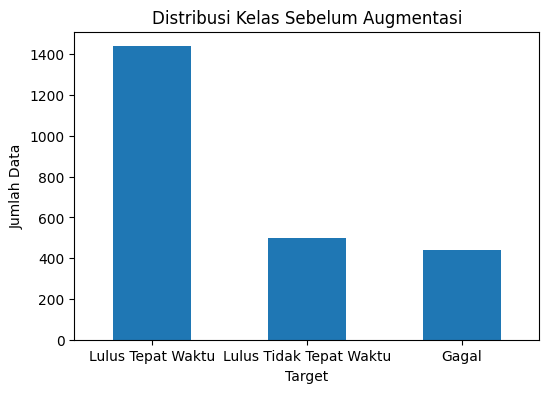

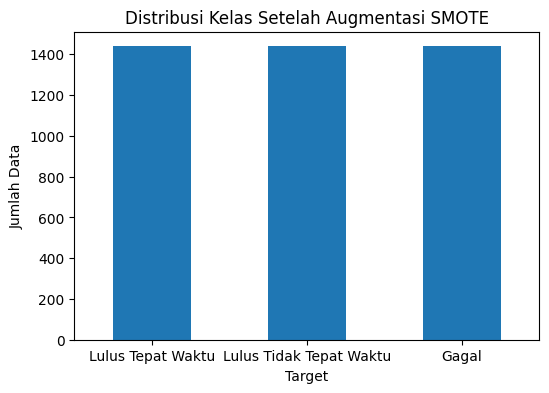

In [37]:
# Grafik distribusi kelas sebelum dan sesudah augmentasi

plt.figure(figsize=(6, 4))
y.value_counts().plot(kind="bar")
plt.title("Distribusi Kelas Sebelum Augmentasi")
plt.xlabel("Target")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()

plt.figure(figsize=(6, 4))
y_resampled.value_counts().plot(kind="bar")
plt.title("Distribusi Kelas Setelah Augmentasi SMOTE")
plt.xlabel("Target")
plt.ylabel("Jumlah Data")
plt.xticks(rotation=0)
plt.show()

In [38]:
# Menggabungkan kembali X_resampled dan y_resampled menjadi dataframe

df_balanced = X_resampled.copy()
df_balanced["Target"] = y_resampled

print("Ukuran data setelah balancing:", df_balanced.shape)
display(df_balanced.head())

Ukuran data setelah balancing: (4317, 44)


,ID,Nilai SMA,Nilai Ujian Masuk,Usia saat mendaftar,IP Semester 1,IP Semester 2,Status Pernikahan_Cerai,Status Pernikahan_Menikah,Program Studi_Akuntansi,Program Studi_Ekonomi,...,Pekerjaan Ibu_Wiraswasta,Pekerjaan Ayah_Pegawai Negri,Pekerjaan Ayah_Pegawai Swasta,Pekerjaan Ayah_Wiraswasta,Pindahan_Ya,Berkebutuhan Khusus_Ya,Status pembayaran semester terakhir_Sudah,Jenis Kelamin_Perempuan,Beasiswa_Ya,Target
0,2,66.55,53.00,21,2.48,2.52,False,False,False,False,...,False,False,False,False,True,False,True,False,False,Lulus Tepat Waktu
1,3,63.50,58.25,19,2.86,2.63,False,False,False,False,...,False,False,True,False,False,False,True,True,True,Lulus Tepat Waktu
2,4,62.50,60.75,18,2.20,2.07,False,False,False,False,...,True,False,False,False,True,False,True,False,False,Lulus Tidak Tepat Waktu
3,5,75.00,75.00,20,2.60,2.40,False,False,False,False,...,False,False,True,False,False,False,True,True,False,Lulus Tidak Tepat Waktu
4,10,65.00,64.55,18,2.61,2.72,False,False,False,False,...,False,True,False,False,True,False,True,True,False,Lulus Tepat Waktu


Selanjutnya datanya perlu kita bagi dengan ratio **$\color{orange}{\text{80}}$** : **$\color{orange}{\text{20}}$**
Dimana **$\color{orange}{\text{80}}$** adalah data training
Dan **$\color{orange}{\text{20}}$** adalah data testing


In [39]:
# 1)	Lakukan pembagian data training dan testing
# ...

from sklearn.model_selection import train_test_split

# Memisahkan fitur dan target
X = df_balanced.drop(columns=["Target"])
y = df_balanced["Target"]

# Membagi data menjadi training dan testing dengan rasio 80:20
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Menampilkan ukuran data hasil pembagian
print("Ukuran X_train:", X_train.shape)
print("Ukuran X_test:", X_test.shape)
print("Ukuran y_train:", y_train.shape)
print("Ukuran y_test:", y_test.shape)

Ukuran X_train: (3453, 43)
Ukuran X_test: (864, 43)
Ukuran y_train: (3453,)
Ukuran y_test: (864,)


In [40]:
# Cek distribusi kelas pada data training dan testing untuk melihat keseimbangan

print("Distribusi kelas pada y_train:")
print(y_train.value_counts())

print("\nDistribusi kelas pada y_test:")
print(y_test.value_counts())

Distribusi kelas pada y_train:
Target
Lulus Tepat Waktu          1151
Lulus Tidak Tepat Waktu    1151
Gagal                      1151
Name: count, dtype: int64

Distribusi kelas pada y_test:
Target
Lulus Tepat Waktu          288
Lulus Tidak Tepat Waktu    288
Gagal                      288
Name: count, dtype: int64


##Task 8
Sekarang kita mulai training nya

In [46]:
# 1)	Lakukan proses training dengan algoritma yang telah dipilih
# ...
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Random Forest
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Melatih model menggunakan data training
model.fit(X_train, y_train)

# Melakukan prediksi pada data testing
y_pred = model.predict(X_test)



In [43]:
# 2)	Lakukan evaluasi model dengan K-fold
# ...
from sklearn.model_selection import cross_val_score, StratifiedKFold

# Membuat Stratified K-Fold
kfold = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Evaluasi model menggunakan cross validation
cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=kfold,
    scoring="accuracy"
)

# Menampilkan hasil evaluasi K-Fold
print("Hasil akurasi setiap fold:")
print(cv_scores)

print("\nRata-rata akurasi K-Fold:", cv_scores.mean())
print("Standar deviasi akurasi K-Fold:", cv_scores.std())

Hasil akurasi setiap fold:
[0.79450072 0.77279305 0.78726483 0.74637681 0.77246377]

Rata-rata akurasi K-Fold: 0.7746798380838524
Standar deviasi akurasi K-Fold: 0.016497162448002468


#Task 9
Training sudah selesai dan model sudah diketahui, kita uji hasilnya dengan data testing untuk melihat kemungkinan overfitting dan underfitting, sekaligus menghitung kualitas model dengan matrik pengukuran

In [47]:
# Prediksi pada data training
y_train_pred = model.predict(X_train)

# Menghitung akurasi training dan testing
akurasi_training = accuracy_score(y_train, y_train_pred)
akurasi_testing = accuracy_score(y_test, y_pred)

print("Akurasi data training:", akurasi_training)
print("Akurasi data testing:", akurasi_testing)

# Selisih akurasi
selisih_akurasi = akurasi_training - akurasi_testing

print("Selisih akurasi training dan testing:", selisih_akurasi)

Akurasi data training: 1.0
Akurasi data testing: 0.7858796296296297
Selisih akurasi training dan testing: 0.21412037037037035


In [48]:
# Interpretasi overfitting / underfitting

if akurasi_training > akurasi_testing and selisih_akurasi > 0.1:
    print("Model kemungkinan mengalami overfitting.")
elif akurasi_training < 0.6 and akurasi_testing < 0.6:
    print("Model kemungkinan mengalami underfitting.")
else:
    print("Model tidak menunjukkan indikasi overfitting atau underfitting yang besar.")

Model kemungkinan mengalami overfitting.


In [44]:
# 1)	Evaluasi dengan data testing
# ...
# Melakukan prediksi pada data testing
y_pred = model.predict(X_test)

# Menghitung akurasi pada data testing
akurasi_testing = accuracy_score(y_test, y_pred)

print("Akurasi pada data testing:", akurasi_testing)



Akurasi pada data testing: 0.7858796296296297


In [45]:
# 2)	Hitung dengan matrik pengukuran
# ...
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Classification Report:
                         precision    recall  f1-score   support

                  Gagal       0.86      0.83      0.84       288
      Lulus Tepat Waktu       0.75      0.83      0.79       288
Lulus Tidak Tepat Waktu       0.76      0.70      0.73       288

               accuracy                           0.79       864
              macro avg       0.79      0.79      0.79       864
           weighted avg       0.79      0.79      0.79       864

Confusion Matrix:
[[238  21  29]
 [ 13 239  36]
 [ 26  60 202]]


##Task 10

Berdasarkan hasil evaluasi, model memperoleh akurasi sebesar 78,59%, artinya model berhasil memprediksi sekitar 78,59% data testing dengan benar. Pada classification report, precision menunjukkan ketepatan prediksi model pada suatu kelas. Misalnya, precision kelas Gagal sebesar 0,86 berarti dari semua data yang diprediksi sebagai Gagal, 86% benar. Recall menunjukkan kemampuan model mengenali data yang sebenarnya termasuk kelas tersebut. Recall kelas Gagal sebesar 0,83 berarti dari seluruh data yang sebenarnya Gagal, 83% berhasil dikenali dengan benar. F1-score adalah gabungan antara precision dan recall, sehingga semakin tinggi nilainya maka performa model semakin baik. Kelas Gagal memiliki F1-score tertinggi yaitu 0,84, sedangkan kelas Lulus Tidak Tepat Waktu memiliki F1-score terendah yaitu 0,73, sehingga kelas tersebut paling sulit dikenali model. Support menunjukkan jumlah data asli pada setiap kelas di data testing, yaitu masing-masing 288 data. Confusion matrix menunjukkan jumlah prediksi benar dan salah pada setiap kelas. Dari confusion matrix, model paling banyak salah ketika data Lulus Tidak Tepat Waktu diprediksi sebagai Lulus Tepat Waktu, yaitu sebanyak 60 data. Evaluasi menggunakan 5-Fold Cross Validation menghasilkan akurasi tiap fold sebesar 79,45%, 77,28%, 78,73%, 74,64%, dan 77,25%, dengan rata-rata akurasi 77,47% dan standar deviasi 1,65%. Hal ini menunjukkan bahwa performa model cukup stabil karena perbedaan akurasi antar fold tidak terlalu besar

Selain itu juga, model memperoleh akurasi 1,00 atau 100% pada data training dan akurasi 0,7859 atau 78,59% pada data testing. Selisih akurasi antara data training dan data testing sebesar 0,2141 atau 21,41%. Selisih yang cukup besar ini menunjukkan bahwa model kemungkinan mengalami overfitting, yaitu kondisi ketika model terlalu baik dalam mempelajari data training tetapi performanya menurun saat diuji pada data testing. Meskipun akurasi testing masih cukup baik, model belum sepenuhnya mampu melakukan generalisasi secara optimal terhadap data baru. Oleh karena itu, model masih dapat ditingkatkan dengan melakukan tuning parameter, mengurangi kompleksitas model, menggunakan cross validation, atau mencoba algoritma lain agar performa pada data testing menjadi lebih stabil.